## WWF Priority Place — Multi-Class Classifier (Amazon · Great Plains · Other)

### 1 · Imports

In [12]:
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
WWF_GREEN  = '#006B3C'
WWF_GOLD   = '#F5A623'
AMAZON_CLR = '#E8742A'
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9'})

### 2 · Keyword Config

In [13]:
# Segment review order per Training_Rules.pdf
SEGMENT_ORDER = [
    'Cost Center',   # Level 1
    'Program Code',  # Level 2
    'Grant',         # Level 3
]

PRIORITY_PLACE_KEYWORDS = {
    'Amazon': {
        'countries': [
            'brazil', 'brasil', 'bolivia', 'bolivie', 'peru', 'perú', 'ecuador',
            'équateur', 'colombia', 'colombie', 'guyana', 'suriname', 'surinam',
            'french guiana', 'guyane',
        ],
        'geo_features': [
            'amazon', 'amazonia', 'amazônia', 'amazonica', 'amazónica',
            'tapajos', 'tapajós', 'madeira', 'xingu', 'negro', 'solimões',
            'solimoes', 'marañón', 'maranon', 'ucayali', 'napo', 'putumayo',
            'jurua', 'juruá', 'purus', 'purús', 'javari', 'japura', 'japurá',
            'madre de dios', 'beni', 'guapore', 'guaporé', 'vaupés', 'vaupes',
            'içá', 'ica river', 'southwest amazon', 'western amazon',
        ],
        'protected_areas': [
            'manu', 'yasuni', 'yasuní', 'madidi', 'tambopata', 'pacaya-samiria',
            'pacaya samiria', 'serra do divisor', 'sierra del divisor',
            'jau national park', 'jaú', 'tumucumaque', 'alto purus', 'alto purús',
            'chiribiquete', 'cordillera azul', 'amboro', 'amboró',
            'beni biosphere', 'pantanal matogrossense',
        ],
        'species': [
            'jaguar', 'onca', 'onça', 'giant otter', 'giant river otter',
            'ariranha', 'tapir', 'anta', 'pink river dolphin', 'boto', 'bufeo',
            'arapaima', 'paiche', 'pirarucu', 'macaw', 'arara', 'harpy eagle',
            'gavião-real', 'giant anteater', 'tamandua', 'giant armadillo',
            'tatu-canastra', 'anaconda', 'sucuri', 'black caiman', 'jacare',
            'jacaré', 'arrau turtle', 'capybara', 'capivara', 'manatee',
            'peixe-boi', 'howler monkey', 'spider monkey', 'woolly monkey',
            'uakari', 'squirrel monkey', 'poison dart frog', 'piranha',
        ],
    },

    'Congo Basin': {
        'countries': [
            'drc', 'democratic republic of congo', 'democratic republic of the congo',
            'dr congo', 'congo', 'kinshasa', 'republic of congo', 'republic of the congo',
            'brazzaville', 'car', 'central african republic', 'gabon', 'cameroon',
            'cameroun', 'equatorial guinea', 'guinée équatoriale', 'rdc', 'roc',
        ],
        'geo_features': [
            'congo river', 'congo basin', 'congo rainforest', 'ubangi', 'sangha',
            'kasai', 'lualaba', 'uele', 'aruwimi', 'lake tumba', 'lake mai-ndombe',
            'cuvette centrale', 'cuvette', 'basin du congo', 'bassin du congo',
            'lobaye', 'ituri', 'kwilu', 'kwango',
        ],
        'protected_areas': [
            'salonga', 'virunga', 'dja', 'odzala', 'nouabale-ndoki', 'nouabalé-ndoki',
            'dzanga-sangha', 'dzanga sangha', 'lope', 'lopé', 'minkebe',
            'tridom', 'ntokou-pikounda', 'ntokou pikounda', 'conkouati-douli',
            'mbam et djerem', 'boumba-bek', 'boumba bek', 'campo maan',
            'lobeke', 'lobéké', 'odzala-kokoua',
        ],
        'species': [
            'gorilla', 'gorille', 'chimpanzee', 'chimpanze', 'bonobo',
            'forest elephant', 'éléphant de forêt', 'okapi', 'bongo',
            'congo peacock', 'paon du congo', 'drill', 'mandrill',
            'red colobus', 'colobus', 'golden potto', 'african forest buffalo',
            'sitatunga', 'bongo antelope', 'pangolin',
        ],
    },

    'Eastern Himalayas': {
        'countries': [
            'bhutan', 'bhoutan', 'druk yul', 'india', 'bharat', 'hindustan',
            'nepal', 'népal',
        ],
        'geo_features': [
            'himalayas', 'himalaya', 'brahmaputra', 'yarlung tsangpo', 'tsangpo',
            'ganges', 'ganga', 'sundarbans', 'terai', 'eastern himalayas',
            'hindu kush', 'arunachal', 'sikkim', 'assam', 'meghalaya',
            'darjeeling', 'bhutan highlands',
        ],
        'protected_areas': [
            'royal manas', 'jigme dorji', 'chitwan', 'sagarmatha', 'kangchenjunga',
            'kanchenjunga', 'namdapha', 'kaziranga', 'manas', 'pakke',
            'bumdeling', 'thrumshingla', 'wangchuck centennial', 'bardia',
            'makalu-barun', 'makalu barun', 'langtang', 'annapurna',
            'phrumsengla', 'sakteng',
        ],
        'species': [
            'snow leopard', 'irbis', 'red panda', 'firefox', 'ailurus',
            'tiger', 'one-horned rhino', 'indian rhinoceros', 'greater one-horned',
            'clouded leopard', 'golden langur', 'ganges river dolphin',
            'gangetic dolphin', 'platanista', 'black-necked crane',
            'bengal florican', 'gharial', 'king cobra', 'himalayan brown bear',
            'asiatic black bear', 'takin', 'gaur', 'wild water buffalo',
        ],
    },

    'Eastern Pacific Seascape': {
        'countries': [
            'colombia', 'ecuador', 'panama', 'panamá', 'costa rica',
        ],
        'geo_features': [
            'eastern tropical pacific', 'eastern pacific', 'cmar',
            'humboldt current', 'galápagos', 'galapagos', 'cocos island',
            'cocos', 'coiba', 'malpelo', 'pacific coast', 'pacific ocean',
            'exclusive economic zone', 'eez', 'pacific seascape',
        ],
        'protected_areas': [
            'galápagos national park', 'galapagos national park', 'galapagos marine reserve',
            'cocos island national park', 'coiba national park',
            'malpelo fauna and flora sanctuary', 'machalilla', 'gorgona',
            'las gemelas', 'darien', 'darién', 'uramba bahia malaga',
        ],
        'species': [
            'marine iguana', 'galápagos tortoise', 'galapagos tortoise',
            'blue-footed booby', 'galápagos penguin', 'whale shark',
            'manta ray', 'hammerhead shark', 'leatherback turtle',
            'hawksbill turtle', 'humpback whale', 'sperm whale',
            'bottlenose dolphin', 'sea turtle', 'mobula', 'sailfish',
        ],
    },

    'Great Plains': {
        'countries': [
            'united states', 'usa', 'u.s.a', 'u.s.', 'america',
            'canada', 'canadá', 'mexico', 'méxico', 'mejico',
        ],
        'geo_features': [
            'great plains', 'northern great plains', 'high plains',
            'llano estacado', 'chihuahuan desert', 'missouri river',
            'platte river', 'yellowstone river', 'prairie', 'grassland',
            'montana', 'wyoming', 'north dakota', 'south dakota',
            'nebraska', 'kansas', 'oklahoma', 'saskatchewan',
            'alberta', 'manitoba', 'sonora', 'chihuahua', 'coahuila',
        ],
        'protected_areas': [
            'yellowstone', 'badlands', 'theodore roosevelt', 'wind cave',
            'grasslands national park', 'tallgrass prairie', 'little missouri',
            'american prairie', 'charles m. russell', 'fort peck',
            'rocky mountain arsenal', 'northern great plains program',
        ],
        'species': [
            'bison', 'american bison', 'buffalo', 'black-footed ferret',
            'prairie dog', 'pronghorn', 'swift fox', 'sage grouse',
            'burrowing owl', 'mountain plover', 'ferruginous hawk',
            'long-billed curlew', 'elk', 'wapiti', 'mule deer',
            'grizzly bear', 'gray wolf', 'wolverine', 'swift fox',
        ],
    },

    'Arctic': {
        'countries': [
            'united states', 'usa', 'alaska', 'canada', 'norway', 'norge',
            'denmark', 'danmark', 'greenland', 'grønland', 'kalaallit nunaat',
            'iceland', 'island', 'finland', 'suomi', 'sweden', 'sverige',
            'russia', 'rossiya',
        ],
        'geo_features': [
            'arctic', 'arctic ocean', 'beaufort sea', 'chukchi sea',
            'bering sea', 'barents sea', 'greenland sea', 'norwegian sea',
            'arctic circle', 'tundra', 'permafrost', 'svalbard', 'spitsbergen',
            'baffin island', 'banks island', 'devon island', 'ellesmere island',
            'northwest territories', 'nunavut', 'yukon', 'lapland',
        ],
        'protected_areas': [
            'arctic national wildlife refuge', 'anwr', 'svalbard global seed vault',
            'wrangel island', 'northeast greenland national park',
            'thelon wildlife sanctuary',
        ],
        'species': [
            'polar bear', 'ursus maritimus', 'walrus', 'odobenus rosmarus',
            'narwhal', 'monodon', 'beluga', 'beluga whale', 'delphinapterus',
            'arctic fox', 'alopex lagopus', 'caribou', 'reindeer', 'rangifer',
            'bowhead whale', 'balaena mysticetus', 'ringed seal', 'pusa hispida',
            'bearded seal', 'musk ox', 'ovibos moschatus', 'snowy owl',
            'arctic tern', 'ivory gull',
        ],
    },

    'Greater Mekong': {
        'countries': [
            'cambodia', 'cambodge', 'kampuchea', 'laos', 'lao pdr', 'lao',
            'myanmar', 'burma', 'birmanie', 'thailand', 'thaïlande', 'thai',
            'vietnam', 'viet nam', 'việt nam', 'indochina', 'indochinese',
        ],
        'geo_features': [
            'mekong', 'mekong river', 'mekong delta', 'lancang', 'irrawaddy',
            'ayeyarwady', 'salween', 'thanlwin', 'chao phraya', 'tonle sap',
            'red river', 'song hong', 'mekong basin', 'greater annamites',
            'dawna tenasserim', 'dawna-tenasserim', 'cardamom mountains',
        ],
        'protected_areas': [
            'cardamom', 'greater annamites', 'dawna tenasserim', 'cat tien',
            'phong nha', 'ke bang', 'phong nha-ke bang', 'pu mat', 'nakai nam theun',
            'xe pian', 'mondulkiri', 'virachey', 'hkakabo razi', 'hukaung valley',
            'inlay lake', 'alaungdaw kathapa', 'indawgyi lake',
        ],
        'species': [
            'mekong giant catfish', 'pangasianodon', 'irrawaddy dolphin',
            'orcaella', 'asian elephant', 'tiger', 'indochinese leopard',
            'saola', 'pseudoryx', 'green peafowl', 'banteng', 'gaur',
            'siamese crocodile', 'giant ibis', 'white-shouldered ibis',
            'fishing cat', 'clouded leopard', 'red-shanked douc',
            'sunda pangolin', 'malayan tapir',
        ],
    },

    'Southern Africa': {
        'countries': [
            'angola', 'namibia', 'zambia', 'zimbabwe', 'botswana', 'south africa',
            'suid-afrika', 'afrique du sud',
        ],
        'geo_features': [
            'zambezi', 'zambezi river', 'okavango', 'kavango', 'limpopo',
            'chobe river', 'victoria falls', 'mosi-oa-tunya', 'kalahari',
            'caprivi strip', 'cuando cubango', 'kafue', 'kaza',
            'kavango zambezi', 'luangwa', 'kariba',
        ],
        'protected_areas': [
            'kaza', 'kavango zambezi transfrontier', 'okavango delta',
            'hwange', 'chobe', 'kruger', 'etosha', 'kafue', 'lower zambezi',
            'gonarezhou', 'mana pools', 'bwabwata', 'mudumu', 'sioma ngwezi',
            'luengue-luiana', 'bangweulu', 'south luangwa', 'north luangwa',
            'moremi', 'central kalahari',
        ],
        'species': [
            'african elephant', 'loxodonta', 'lion', 'panthera leo', 'leopard',
            'cheetah', 'acinonyx', 'white rhino', 'black rhino', 'rhinoceros',
            'african wild dog', 'lycaon pictus', 'painted dog', 'hippo',
            'hippopotamus', 'giraffe', 'buffalo', 'african buffalo', 'hyena',
            'spotted hyena', 'pangolin', 'sable antelope', 'roan antelope',
            'lechwe', 'sitatunga', 'wild dog',
        ],
    },

    'Southwest Indian Ocean': {
        'countries': [
            'madagascar', 'malagasy', 'malgache', 'mozambique', 'moçambique',
            'tanzania', 'tanzanie', 'timor leste', 'timor-leste', 'east timor',
            'mauritius', 'île maurice', 'comoros', 'comores', 'seychelles',
            'reunion', 'réunion', 'la réunion',
        ],
        'geo_features': [
            'mozambique channel', 'indian ocean', 'southwest indian ocean', 'swio',
            'malagasy', 'tsiribihina', 'manambolo', 'betsiboka', 'rufiji',
            'ruvuma', 'rovuma', 'northern mozambique', 'comoro islands',
            'mascarene islands',
        ],
        'protected_areas': [
            'quirimbas', 'bazaruto', 'tsingy de bemaraha', 'tsingy',
            'ranomafana', 'isalo', 'andasibe', 'masoala', 'belo sur tsiribihina',
            'pemba', 'mafia island', 'mnazi bay', 'selous', 'niassa',
            'gorongosa', 'zinave', 'chimanimani',
        ],
        'species': [
            'lemur', 'ring-tailed lemur', 'aye-aye', 'daubentonia', 'indri',
            'sifaka', 'propithecus', 'fossa', 'cryptoprocta', 'tenrec',
            'coelacanth', 'latimeria', 'dugong', 'dugong dugon', 'hawksbill',
            'green turtle', 'humpback whale', 'whale shark', 'manta ray',
            'comet grouper', 'napoleon wrasse',
        ],
    },

    'SW Pacific + Indonesia': {
        'countries': [
            'indonesia', 'indonésie', 'indonesian', 'philippines', 'pilipinas',
            'filipino', 'philippine', 'papua new guinea', 'png', 'papua',
        ],
        'geo_features': [
            'coral triangle', 'borneo', 'sumatra', 'sumatera', 'java', 'jawa',
            'sulawesi', 'celebes', 'papua', 'kalimantan', 'irian jaya',
            'banda sea', 'bismarck sea', 'solomon sea', 'sulu sea',
            'celebes sea', 'new guinea', 'melanesia', 'wallacea',
            'heart of borneo', 'raja ampat', 'bird\'s head seascape',
        ],
        'protected_areas': [
            'raja ampat', 'komodo', 'lorentz', 'tubbataha', 'apo reef',
            'heart of borneo', 'gunung leuser', 'leuser', 'tanjung puting',
            'kutai', 'betung kerihun', 'kayan mentarang', 'crocker range',
            'danum valley', 'kinabalu', 'coral triangle initiative',
        ],
        'species': [
            'orangutan', 'pongo', 'sumatran tiger', 'sumatran rhino',
            'dicerorhinus', 'pygmy elephant', 'bornean pygmy elephant',
            'komodo dragon', 'varanus komodoensis', 'bird of paradise',
            'paradisaea', 'cassowary', 'proboscis monkey', 'nasalis',
            'bornean orangutan', 'sumatran orangutan', 'sun bear', 'helarctos',
            'clouded leopard', 'babirusa', 'anoa', 'maleo', 'irrawaddy dolphin',
        ],
    },
}

print(f"Loaded lookup tables for {len(PRIORITY_PLACE_KEYWORDS)} priority places:")
for pp in PRIORITY_PLACE_KEYWORDS:
    total = sum(len(v) for v in PRIORITY_PLACE_KEYWORDS[pp].values())
    print(f"  {pp}: {total} keywords")

Loaded lookup tables for 10 priority places:
  Amazon: 108 keywords
  Congo Basin: 79 keywords
  Eastern Himalayas: 68 keywords
  Eastern Pacific Seascape: 48 keywords
  Great Plains: 64 keywords
  Arctic: 70 keywords
  Greater Mekong: 71 keywords
  Southern Africa: 70 keywords
  Southwest Indian Ocean: 70 keywords
  SW Pacific + Indonesia: 71 keywords


### 3 · Pipeline 1 — Rule-Based Keyword Scan

In [14]:
def rule_scan_row(row, place_keywords=PRIORITY_PLACE_KEYWORDS, segment_order=SEGMENT_ORDER):
    for segment in segment_order:
        text = str(row.get(segment) or '').lower()
        for place, categories in place_keywords.items():
            all_keywords = [kw for kws in categories.values() for kw in kws]
            if any(kw in text for kw in all_keywords):
                return place
    return None

def apply_rules(df):
    return df.apply(rule_scan_row, axis=1)

### 4 · Load Data & Build Training Set

In [15]:
raw = pd.read_csv('Model Training Data.csv', encoding='latin1')
raw.columns = raw.columns.str.strip()
raw.drop(columns=['Unnamed: 7', 'Unnamed: 8'], inplace=True, errors='ignore')

pp = raw['Priority Place'].astype(str).str.strip()

# Exclude multi-label rows (e.g. "Amazon, SWIO") from training
multi_label_mask  = pp.str.contains(',', na=False)
amazon_mask       = pp.str.contains('Amazon', na=False) & ~multi_label_mask
great_plains_mask = pp.str.contains('Great Plains', na=False) & ~multi_label_mask
other_mask        = raw['Priority Place'].notna() & ~amazon_mask & ~great_plains_mask & ~multi_label_mask

raw['label'] = np.where(amazon_mask, 1,
               np.where(great_plains_mask, 2,
               np.where(other_mask, 0, -1)))
train_df = raw[raw['label'] != -1].copy()

print(f"Pre-tagged Amazon (label=1)       : {int((train_df['label']==1).sum())}")
print(f"Pre-tagged Great Plains (label=2) : {int((train_df['label']==2).sum())}")
print(f"Pre-tagged Other (label=0)        : {int((train_df['label']==0).sum())}")
print(f"Multi-label (excluded)            : {int(multi_label_mask.sum())}")

# Augment: run rule-based scan on untagged rows
untagged = raw[raw['label'] == -1].copy()
untagged['rule_tag'] = apply_rules(untagged)
rule_amazon_mask = untagged['rule_tag'] == 'Amazon'
rule_gp_mask     = untagged['rule_tag'] == 'Great Plains'
rule_other_mask  = untagged['rule_tag'].notna() & ~rule_amazon_mask & ~rule_gp_mask
untagged['label'] = np.where(rule_amazon_mask, 1,
                    np.where(rule_gp_mask, 2,
                    np.where(rule_other_mask, 0, -1)))
rule_tagged = untagged[untagged['label'] != -1].copy()

train_df = pd.concat([train_df, rule_tagged], ignore_index=True)

print(f"\nAfter rule augmentation:")
print(f"  Rule-tagged Amazon added       : {int(rule_amazon_mask.sum())}")
print(f"  Rule-tagged Great Plains added : {int(rule_gp_mask.sum())}")
print(f"  Rule-tagged Other added        : {int(rule_other_mask.sum())}")
print(f"  Total training rows            : {len(train_df)}")


Pre-tagged Amazon (label=1)       : 49
Pre-tagged Great Plains (label=2) : 84
Pre-tagged Other (label=0)        : 139
Multi-label (excluded)            : 10

After rule augmentation:
  Rule-tagged Amazon added       : 37
  Rule-tagged Great Plains added : 10
  Rule-tagged Other added        : 51
  Total training rows            : 370


### 4b · Augment with Actuals FY25

In [16]:
_raw_hdr = pd.read_csv('Actuals_FY25(FY25 2026-03-09 12_11 AKDT).csv', encoding='latin1', header=None, nrows=20)
CC_NAME_MAP = {}
for entry in str(_raw_hdr.iloc[9, 1]).split('\n\n'):
    entry = entry.strip()
    parts = entry.split(' ', 1)
    if len(parts) == 2:
        CC_NAME_MAP[parts[0]] = entry

GR_NAME_MAP = {}
for v in raw['Grant'].dropna().unique():
    code = str(v).split()[0]
    GR_NAME_MAP[code] = str(v).strip()

actuals = pd.read_csv(
    'Actuals_FY25(FY25 2026-03-09 12_11 AKDT).csv',
    encoding='latin1', header=19, low_memory=False,
)
actuals.columns = actuals.columns.str.strip()
actuals = actuals.rename(columns={'Program': 'Program Code'})
actuals['Cost Center'] = actuals['Cost Center'].astype(str).str.strip().map(lambda c: CC_NAME_MAP.get(c, c))
actuals['Grant']       = actuals['Grant'].astype(str).str.strip().map(lambda g: GR_NAME_MAP.get(g, g))

actuals_dedup = actuals[['Cost Center', 'Program Code', 'Grant']].drop_duplicates().copy()
actuals_dedup['label'] = -1

actuals_dedup['rule_tag'] = apply_rules(actuals_dedup)
act_amazon_mask = actuals_dedup['rule_tag'] == 'Amazon'
act_gp_mask     = actuals_dedup['rule_tag'] == 'Great Plains'
act_other_mask  = actuals_dedup['rule_tag'].notna() & ~act_amazon_mask & ~act_gp_mask
actuals_dedup['label'] = np.where(act_amazon_mask, 1,
                          np.where(act_gp_mask, 2,
                          np.where(act_other_mask, 0, -1)))
actuals_tagged = actuals_dedup[actuals_dedup['label'] != -1].copy()

train_df = pd.concat([train_df, actuals_tagged], ignore_index=True)

print(f"Actuals unique CC/Program/Grant combos : {len(actuals_dedup):,}")
print(f"  Rule-tagged Amazon                   : {int(act_amazon_mask.sum())}")
print(f"  Rule-tagged Great Plains             : {int(act_gp_mask.sum())}")
print(f"  Rule-tagged Other                    : {int(act_other_mask.sum())}")
print(f"  Total training rows after Actuals    : {len(train_df):,}")


Actuals unique CC/Program/Grant combos : 3,978
  Rule-tagged Amazon                   : 285
  Rule-tagged Great Plains             : 188
  Rule-tagged Other                    : 490
  Total training rows after Actuals    : 1,333


### 5 · Pipeline 2 — ML Model

In [17]:
TEXT_COLS = SEGMENT_ORDER + ['Country', 'Big Bet']

def make_text(row):
    parts = [str(row.get(c, '') or '') for c in TEXT_COLS]
    return ' '.join(p for p in parts if p and p.lower() not in ('nan', ''))

train_df['text'] = train_df.apply(make_text, axis=1)
X = list(train_df['text'])
y = list(train_df['label'].astype(int))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ml_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=1, max_features=50000, sublinear_tf=True,
    )),
    ('rf', RandomForestClassifier(
        n_estimators=500, class_weight='balanced_subsample', n_jobs=-1, random_state=42,
    )),
])
ml_pipe.fit(X_train, y_train)
print('Model trained.')


Model trained.


### 6 · Evaluate ML Pipeline

In [18]:
CLASS_NAMES = {0: 'Other', 1: 'Amazon', 2: 'Great Plains'}
label_names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]

y_pred = ml_pipe.predict(X_test)

print(f'Test accuracy : {accuracy_score(y_test, y_pred)*100:.1f}%')
print()
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

from sklearn.base import clone
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_arr, y_arr = np.array(X), np.array(y)
fold_accs = []
for tr_idx, te_idx in cv.split(X_arr, y_arr):
    p = clone(ml_pipe)
    p.fit(X_arr[tr_idx], y_arr[tr_idx])
    yp = p.predict(X_arr[te_idx])
    fold_accs.append(accuracy_score(y_arr[te_idx], yp))

print(f'CV scores : {[f"{a*100:.1f}%" for a in fold_accs]}')
print(f'CV mean   : {np.mean(fold_accs)*100:.1f}%  +/-  {np.std(fold_accs)*100:.1f}%')
print(f'Target    : 80.0%  ->  {"PASS!" if np.mean(fold_accs) >= 0.80 else "FAIL :("}')


Test accuracy : 97.8%

              precision    recall  f1-score   support

       Other       0.98      0.98      0.98       136
      Amazon       0.96      0.96      0.96        74
Great Plains       1.00      1.00      1.00        57

    accuracy                           0.98       267
   macro avg       0.98      0.98      0.98       267
weighted avg       0.98      0.98      0.98       267

CV scores : ['97.8%', '99.3%', '97.4%', '98.1%', '98.1%']
CV mean   : 98.1%  +/-  0.6%
Target    : 80.0%  ->  PASS!


### 6b · Top TF-IDF Features by Importance

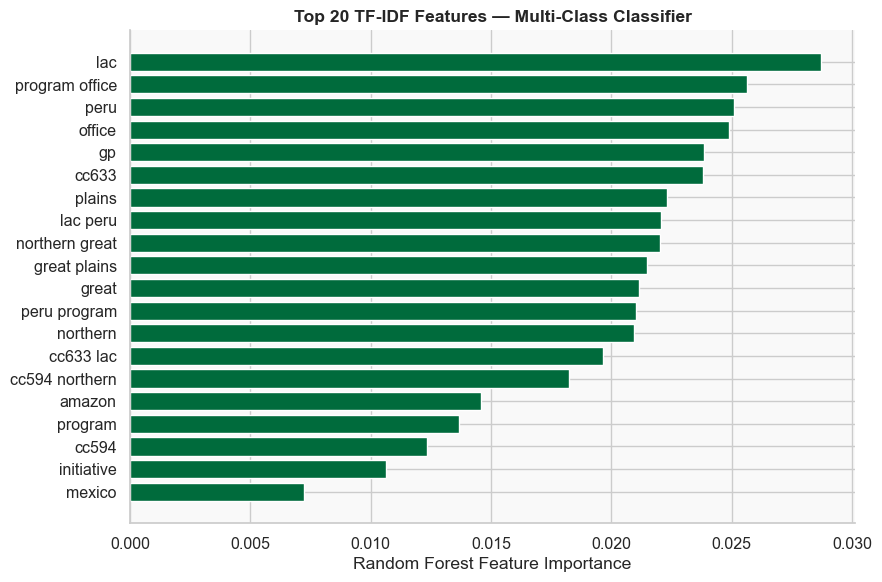

       feature  importance
           lac    0.028703
program office    0.025615
          peru    0.025095
        office    0.024891
            gp    0.023866
         cc633    0.023803
        plains    0.022292
      lac peru    0.022069
northern great    0.022006
  great plains    0.021484
         great    0.021147
  peru program    0.021034
      northern    0.020934
     cc633 lac    0.019641
cc594 northern    0.018257
        amazon    0.014578
       program    0.013679
         cc594    0.012321
    initiative    0.010638
        mexico    0.007232


In [19]:
feature_names = ml_pipe.named_steps['tfidf'].get_feature_names_out()
importances   = ml_pipe.named_steps['rf'].feature_importances_

feat_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=WWF_GREEN)
ax.set_xlabel('Random Forest Feature Importance')
ax.set_title('Top 20 TF-IDF Features — Multi-Class Classifier', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))


### 6c · SHAP Feature Directionality

In [ ]:
import shap

X_test_tfidf = ml_pipe.named_steps['tfidf'].transform(X_test).toarray().astype(float)
explainer    = shap.TreeExplainer(ml_pipe.named_steps['rf'])
shap_values  = explainer.shap_values(X_test_tfidf, check_additivity=False)

# shap_values shape: (samples, features, classes) or list of arrays
if isinstance(shap_values, list):
    sv_amazon      = shap_values[1]  # class 1 = Amazon
    sv_great_plains = shap_values[2]  # class 2 = Great Plains
else:
    sv_amazon      = shap_values[:, :, 1]
    sv_great_plains = shap_values[:, :, 2]

for sv, title in [(sv_amazon, 'Amazon'), (sv_great_plains, 'Great Plains')]:
    shap.summary_plot(sv, X_test_tfidf, feature_names=feature_names,
                      max_display=15, plot_type='dot', show=False)
    plt.title(f'SHAP Values — {title}', fontweight='bold')
    plt.tight_layout()
    plt.show()


### 7 · Apply Both Pipelines to All Rows

In [21]:
raw['text']      = raw.apply(make_text, axis=1)
raw['final_tag'] = ml_pipe.predict(raw['text'].tolist())
raw['final_tag'] = raw['final_tag'].map({0: None, 1: 'Amazon', 2: 'Great Plains'})

for place in ['Amazon', 'Great Plains']:
    print(f'{place}: {int((raw["final_tag"] == place).sum())} rows tagged')

# Sanity check on originally labeled rows
labeled = raw[raw['label'] != -1].copy()
y_true  = labeled['label'].astype(int).tolist()
y_pred  = labeled['final_tag'].map({'Amazon': 1, 'Great Plains': 2}).fillna(0).astype(int).tolist()

print(f'\nAccuracy on originally labeled rows : {accuracy_score(y_true, y_pred)*100:.1f}%')
print(classification_report(y_true, y_pred,
      target_names=['Other', 'Amazon', 'Great Plains'], zero_division=0))


Amazon: 122 rows tagged
Great Plains: 94 rows tagged

Accuracy on originally labeled rows : 98.9%
              precision    recall  f1-score   support

       Other       1.00      0.98      0.99       139
      Amazon       0.94      1.00      0.97        49
Great Plains       1.00      1.00      1.00        84

    accuracy                           0.99       272
   macro avg       0.98      0.99      0.99       272
weighted avg       0.99      0.99      0.99       272

